In [5]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import plotly.figure_factory as ff
from sklearn.impute import SimpleImputer

import scipy as scp

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.metrics import confusion_matrix

import statsmodels.api as sm
import matplotlib.pyplot as plt


import statsmodels.formula.api as smf
import statsmodels.api as sm

import statsmodels.api as sm
import pandas as pd

In [6]:
#########################Get Data############################
path = 'D:/Users/Owner/Desktop/Navy Fed Data Set/'
raw_data = pd.read_excel(path + 'Lending Analytics Assessment.xlsx')
#############################################################
pd.set_option('display.max_columns', None)

raw_data.head() 


FileNotFoundError: [Errno 2] No such file or directory: 'D:/Users/Owner/Desktop/Navy Fed Data Set/Lending Analytics Assessment.xlsx'

In [284]:
#########################################################################
#                            Design Matrix                              #
#########################################################################


###########################################################################
# N/A is considered a 0 for this data set with respect to Num_times_DQ_L12 Therefore No need to remove data.
# Fills N\A's with 0's
###########################################################################

raw_data['Num_times_DQ_L12'] = raw_data['Num_times_DQ_L12'].fillna(0)



############################################################
# Impute Origionation_LTV and Liquid_Dept_Amt Data First
###########################################################
imputer = SimpleImputer(missing_values = np.nan,strategy = 'mean')
raw_data[['Origination_LTV','Liquid_Dep_Amt']]=imputer.fit_transform(raw_data[['Origination_LTV','Liquid_Dep_Amt']])



############################################################################################
# X_Super light  Drop Due to Correlation between in Output and Input Varaibles  09.09.2022 #
############################################################################################

# This is correlated with: Curr_Prin_Amt_Pdue  with DQ_TOT_DAYS_PDUE

# Current_Prinicipal_Amt_Past_Due
# CURR_TERM vs. Orig_Term  -Take out CURR_TERM 

# Orig_Loan_Amt vs.  Current_Balance  - Take out Orig Loan Amt



X = raw_data.drop(["Region","RT_NUM_PMTS_REM","Loan_ID","COLL_CD","Charge_Off_Amt",
                   "DQ_TOT_DAYS_PDUE","ChargeOff_Flag",
                   "Orig_Loan_Amt","Curr_Prin_Amt_Pdue", "CURR_TERM",   # This Line 
                   "Open_Date","Loan_ID","Num_times_DQ_L12",
                   "Last_Paymt_Amt", "MOD_DATE","MOD_REASON","ChgoffDate","last_date_active",
                   "Direct_Deposit_flag","DQ1_flag" ,"DQ30_flag","DQ90_flag","DQ60_flag","DQ120_flag",
                   "Ever_Modified_flag", "Current_FICO_Tier", "New_Member_Flag",
                    "status_asof_last_date","Curr_DQ_Status", "origin_group","Last_Paymt_Amt",
                    "Scheduled_Pmt_Amt","FT_Orig"],axis=1) # Here was want to drop the columns (axis = 1)
raw_data

,Loan_ID,COLL_CD,APR,Open_Date,Orig_Term,Orig_Loan_Amt,Dep_Loan_Seg_Desc,Current_Balance,Last_Paymt_Amt,DQ_TOT_DAYS_PDUE,RT_NUM_PMTS_REM,Scheduled_Pmt_Amt,CURR_TERM,RT_NUM_PMTS_MADE,Curr_Prin_Amt_Pdue,Num_times_DQ_L12,Product,Liquid_Dep_Amt,length_of_membership_mnths,lending_prod_cnt,origin_group,Length_Of_Mbrshp_Range,Curr_DQ_Status,Orig_Tier,Direct_Deposit_flag,Origination_LTV,MOD_DATE,MOD_REASON,ChgoffDate,Charge_Off_Amt,ChargeOff_Flag,last_date_active,status_asof_last_date,current_months_on_books,Current_FICO_Tier,Region,New_Member_Flag,DQ1_flag,DQ30_flag,DQ60_flag,DQ90_flag,DQ120_flag,Generation,Never_DQ_flag,Product.Bucket,FT_Orig,Ever_Modified_flag
0,1,TVO,3.59,2010-07-19,36,9759.62,Not Assigned,8325.32,293.627895,0,30,293.627895,36,6,0.000000,2.0,Used_Vehicle,12.3671,70,2,Other,15 to 19 Years,DQ0,A+,1,125.430000,NaT,NaN,NaT,0.0000,0,2013-07-31,PF,36,A+,South Atlantic,0,0,0,0,0,0,Boomers,0,Used_Vehicle,No,0
1,2,TVO,2.99,2015-07-20,60,8667.29,Low Deposit/No Loan,8667.29,0.000000,0,60,156.042737,61,0,0.000000,0.0,Used_Vehicle,232.0930,46,1,Other,5 to 9 Years,DQ0,A+,0,52.510000,NaT,NaN,NaT,0.0000,0,2015-08-31,PF,1,FT,South Atlantic,0,0,0,0,0,0,Millenials,1,Used_Vehicle,No,0
2,3,TVO,5.75,2008-04-15,72,21935.21,Low Deposit/High Loan,2132.71,550.980275,0,4,550.980275,73,68,0.000000,0.0,New_Vehicle,788.1598,93,2,Other,20 to 24 Years,DQ0,A,0,87.634745,NaT,NaN,NaT,0.0000,0,2014-05-31,PF,73,A+,South Atlantic,0,0,0,0,0,0,Gen X,1,New_Vehicle,No,0
3,4,TVO,11.05,2014-05-22,24,5017.29,Low Deposit/High Loan,3935.66,254.345137,10,16,254.231901,24,7,217.726406,1.0,Other,12.7572,51,1,Other,10 to 14 Years,DQ0,C-,1,64.930000,NaT,NaN,NaT,0.0000,0,2015-08-31,PF,15,C,South Atlantic,0,1,0,0,0,0,Boomers,0,Other,No,0
4,5,TVO,5.00,2007-05-23,72,16404.56,Low Deposit/No Loan,15688.39,265.565085,0,68,265.565085,73,4,0.000000,2.0,Late_Model_Used_Vehicle,1387.2455,208,2,Other,25 Years or Ove,DQ0,A+,1,87.634745,NaT,NaN,NaT,0.0000,0,2008-02-29,PF,9,A,Other,0,0,0,0,0,0,Gen X,0,Late_Model_Used_Vehicle,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,TVO,16.94,2013-01-22,72,10096.19,Not Assigned,9306.99,228.499797,0,61,228.499797,73,11,0.000000,2.0,Used_Vehicle,1630.0039,0,2,Other,5 to 9 Years,DQ0,FT,0,72.590000,NaT,NaN,2016-07-27,7369.1091,1,NaT,CF,42,D,Pacific,1,0,0,0,0,0,Millenials,0,Used_Vehicle,Yes,0
9996,9997,TVO,12.49,2011-04-14,60,6696.29,Low Deposit/High Loan,6252.19,83.740240,0,58,167.472351,61,4,0.000000,0.0,Used_Vehicle,83.7886,66,1,Family,15 to 19 Years,DQ0,C-,1,104.010000,NaT,NaN,NaT,0.0000,0,2015-10-31,PF,54,C-,South Atlantic,0,0,0,0,0,0,Millenials,1,Used_Vehicle,No,0
9997,9998,TVO,1.99,2013-11-19,72,21423.31,High Deposit/High Loan,8355.27,331.884856,0,28,331.884856,72,46,0.000000,0.0,New_Vehicle,7987.9699,272,5,Other,25 Years or Ove,DQ0,A+,0,114.290000,NaT,NaN,NaT,0.0000,0,2019-05-31,PF,66,A+,Pacific,0,0,0,0,0,0,Boomers,1,New_Vehicle,No,0
9998,9999,TVO,8.50,2006-09-12,72,25439.24,High Deposit/High Loan,18506.30,229.940481,0,48,459.873401,73,24,0.000000,2.0,Used_Vehicle,1745.5233,115,2,Other,20 to 24 Years,DQ0,C,1,87.634745,NaT,NaN,NaT,0.0000,0,2012-10-31,PF,73,B-,South Atlantic,0,0,0,0,0,0,Gen X,0,Used_Vehicle,No,0


In [285]:
#########################################################################
#                        One Hot Encoding                               #
#########################################################################

X= pd.get_dummies(X,columns = ["Orig_Tier", "Dep_Loan_Seg_Desc",
                                             "Product","Length_Of_Mbrshp_Range",
                                            "Generation", "Product.Bucket"],drop_first=True)

X.head()

,APR,Orig_Term,Current_Balance,RT_NUM_PMTS_MADE,Liquid_Dep_Amt,length_of_membership_mnths,lending_prod_cnt,Origination_LTV,current_months_on_books,Never_DQ_flag,Orig_Tier_A+,Orig_Tier_B,Orig_Tier_B-,Orig_Tier_C,Orig_Tier_C-,Orig_Tier_D,Orig_Tier_D-,Orig_Tier_E,Orig_Tier_FT,Dep_Loan_Seg_Desc_High Deposit/High Loan,Dep_Loan_Seg_Desc_High Deposit/Low Loan,Dep_Loan_Seg_Desc_High Deposit/No Loan,Dep_Loan_Seg_Desc_Inactive Share Savings Only,Dep_Loan_Seg_Desc_Low Deposit/High Loan,Dep_Loan_Seg_Desc_Low Deposit/Low Loan,Dep_Loan_Seg_Desc_Low Deposit/No Loan,Dep_Loan_Seg_Desc_Not Assigned,Product_Boats_Used,Product_Late_Model_Used_Vehicle,Product_Motorcycle_New,Product_Motorcycle_Used,Product_New_Vehicle,Product_Other,Product_Refi_Collections,Product_Share_Collateralized,Product_Used_Vehicle,Length_Of_Mbrshp_Range_15 to 19 Years,Length_Of_Mbrshp_Range_20 to 24 Years,Length_Of_Mbrshp_Range_25 Years or Ove,Length_Of_Mbrshp_Range_5 to 9 Years,Length_Of_Mbrshp_Range_Under 5 Years,Generation_Gen X,Generation_Gen Z,Generation_Millenials,Generation_Silent,Product.Bucket_Boats_Used,Product.Bucket_Late_Model_Used_Vehicle,Product.Bucket_Motorcycle_New,Product.Bucket_Motorcycle_Used,Product.Bucket_New_Vehicle,Product.Bucket_Other,Product.Bucket_Refi_Collections,Product.Bucket_Share_Collateralized,Product.Bucket_Used_Vehicle
0,3.59,36,8325.32,6,12.3671,70,2,125.430000,36,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,2.99,60,8667.29,0,232.0930,46,1,52.510000,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1
2,5.75,72,2132.71,68,788.1598,93,2,87.634745,73,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
3,11.05,24,3935.66,7,12.7572,51,1,64.930000,15,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,5.00,72,15688.39,4,1387.2455,208,2,87.634745,9,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0


In [4]:
########################################################################
#    Target                                                            #
########################################################################

###########################################################
#  Target1  and Target2                                   #
###########################################################
y_norm = raw_data["ChargeOff_Flag"].value_counts(normalize = True)

target1 = ((raw_data['DQ60_flag'] + raw_data['DQ90_flag'] + raw_data['DQ120_flag'] + raw_data["ChargeOff_Flag"] )>0 )*1

####### Test Target 1 #########################
# print(target.value_counts())
# print(target.value_counts(normalize = True))

######   Another Way to get Target 1 #########
target2 = (((raw_data['DQ_TOT_DAYS_PDUE' ]>60)*1 +  (raw_data["ChargeOff_Flag"]))>0)*1
target2
print(raw_data['DQ_TOT_DAYS_PDUE' ]>60)

################## Test Target 2 ##############
# print(target2.value_counts())
# print(target2.value_counts(normalize = True))


NameError: name 'raw_data' is not defined

In [287]:
###############################################################################
###############################################################################
# Set up Training /Test Data Sets                                             #
###############################################################################
###############################################################################

###################################################
# Y is target2                                    #
###################################################

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, target2, test_size = 0.20, random_state = 5)

#### Test Test/Train Split ####
# print(X_train.shape)
# print(X_test.shape)
# print(y_train.shape)
# print(y_test.shape)

# Instantiate Scalar
scaler = MinMaxScaler()

# Only transfrom Training Data
X_train_scaled = scaler.fit_transform(X_train) # fit only on the train and not on test data hence the reason for fit_transfrom

# Do Not Transform Test Data  
X_test_scaled = scaler.transform(X_test)

# print(X_test_scaled)


In [288]:
X_train_scaled

array([[0.55555555, 0.33908046, 0.06550168, ..., 0.        , 0.        ,
        1.        ],
       [0.09944444, 0.31034483, 0.13948153, ..., 0.        , 0.        ,
        0.        ],
       [0.82166667, 0.31034483, 0.03456564, ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.32777777, 0.31034483, 0.0621975 , ..., 0.        , 0.        ,
        1.        ],
       [0.71055555, 0.37931034, 0.06061132, ..., 0.        , 0.        ,
        1.        ],
       [0.5       , 0.37931034, 0.10812817, ..., 0.        , 0.        ,
        0.        ]])

In [290]:
###############################################################################
###############################################################################
# Fit Logistic Regression Model 1  with L1 penalty                            #
# SK learn not a statistical approach                                         # 
###############################################################################
###############################################################################
model1 = LogisticRegression(random_state=0, penalty='l1', solver='liblinear',fit_intercept=True).fit(X_train_scaled, y_train)

preds = model1.predict(X_test_scaled)

### Check ###########
print(preds.shape)

params = model1.get_params()
### Check ###########
print(params)

#### Check Print model parameters ########
print('Intercept: \n', model1.intercept_)
print('Coefficients: \n', model1.coef_)

(2000,)
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l1', 'random_state': 0, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
Intercept: 
 [-5.82015089]
Coefficients: 
 [[ 7.67700224e-01  3.37523186e+00  3.04650686e+00 -3.66717229e-01
   0.00000000e+00  1.08312312e+00  4.78676188e+00  0.00000000e+00
  -9.38783366e-01 -1.06073998e+00 -1.05154020e+00  0.00000000e+00
   1.95415800e-01  2.66052182e-01  3.92219602e-01  5.91387209e-01
   1.20389418e+00  9.12316850e-01  5.27448287e-01 -1.95494701e+00
  -4.79344874e-01  5.83489301e-01  0.00000000e+00 -9.79043225e-01
   0.00000000e+00  2.68673062e+00  3.82578696e+00  0.00000000e+00
   0.00000000e+00 -1.51103994e-04  4.99179723e-01 -3.13850667e-02
   0.00000000e+00  8.14353468e-04  0.00000000e+00  9.08898274e-03
  -4.60155318e-01 -3.61706087e-01 -7.62825999e-01  2.27094531e-01
   7.594586

In [291]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)

X_test_scaled = pd.DataFrame(X_test_scaled,columns = X_test.columns)

y_train = pd.DataFrame({'y_train':y_train}).reset_index().drop(['index'],axis = 1 )
y_test = pd.DataFrame({'y_test':y_test}).reset_index().drop(['index'],axis = 1 )


In [295]:
#########################################
#   VIF 
########################################

from statsmodels.stats.outliers_influence import variance_inflation_factor
X_temp = X_train_scaled
vif_data = pd.DataFrame()
vif_data["feature"] = X_temp.columns
vif_data["VIF"] = [variance_inflation_factor(X_temp.values, i)
                          for i in range(len(X_temp.columns))]
  # sort_values(by ='VIF')
varsToUse = vif_data[vif_data['VIF']<5].feature.to_list()

varsToUse.remove('Dep_Loan_Seg_Desc_Inactive Share Savings Only')

varsToUse.remove('Liquid_Dep_Amt')

varsToUse.remove('lending_prod_cnt')

C:\Users\Owner\anaconda4\lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


In [300]:
###############################################################################
###############################################################################
# Fit Logistic Regression Stats Model                                         #
###############################################################################
###############################################################################



X_train_scaled2 = sm.add_constant(X_train_scaled[varsToUse])

X_test_scaled2 = sm.add_constant(X_test_scaled[varsToUse])
# y_train = pd.DataFrame({'y_train':y_train}) # convert to df 
logit_model=sm.Logit(y_train,X_train_scaled2)
result=logit_model.fit()

####### Print for Presentation ################
print(result.summary())



Optimization terminated successfully.
         Current function value: 0.209494
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                y_train   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7980
Method:                           MLE   Df Model:                           19
Date:                Sun, 11 Sep 2022   Pseudo R-squ.:                  0.1361
Time:                        17:10:23   Log-Likelihood:                -1676.0
converged:                       True   LL-Null:                       -1940.0
Covariance Type:            nonrobust   LLR p-value:                6.818e-100
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -2.9910      

train_AUC 0.7814937156031913
test_AUC 0.7675544254104212


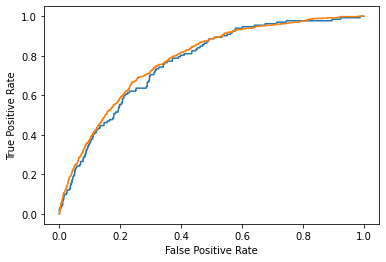

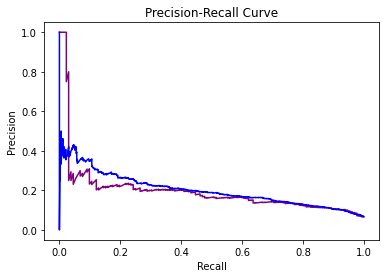

In [301]:
####################################################################
# ROC Curve with SM Model 
###################################################################

#### y_pred_test = model1.predict_proba(X_test_scaled)[::,1]   # Predictions 
### Probs ### 
# y_pred_test = result.predict(X_test_scaled)
# y _pred_test 

y_pred_test = result.predict(X_test_scaled2)
y_pred_train = result.predict(X_train_scaled2)
 
# y_pred_test = results.predict_proba(X_test_scaled)[::,1]  
 
fpr, tpr, _ = metrics.roc_curve(y_test,y_pred_test)
fpr1, tpr1, _ = metrics.roc_curve(y_train,y_pred_train)

#create ROC curve
plt.plot(fpr,tpr)
plt.plot(fpr1,tpr1)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

print("train_AUC", metrics.auc(fpr1, tpr1))
print("test_AUC", metrics.auc(fpr, tpr))

# Proportioins because of proportions of failures is lower than successes  
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

#calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_test)

precision1, recall1, thresholds = precision_recall_curve(y_train, y_pred_train)

#create precision recall curve 
# Key to the calculation of precision and recall is that the calculations do not make use of the true negatives. 
# It is only concerned with the correct prediction of the minority class, class 1.
fig, ax = plt.subplots()
ax.plot(recall, precision, color='purple')
ax.plot(recall1, precision1, color='blue')

#add axis labels to plot
ax.set_title('Precision-Recall Curve')
ax.set_ylabel('Precision')
ax.set_xlabel('Recall')

#display plot
plt.show()